# Breast Cancer Prediction
**Mohammed EL-ASYOUTE** — Algorithms: Logistic Regression · SVM · KNN · K-Means · Decision Tree (ID3)

## 1. Imports

In [38]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, ConfusionMatrixDisplay)
from scipy.stats import mode
print('Imports OK')

Imports OK


## 2. Data Preprocessing

In [39]:
df = pd.read_csv('breastCancer.csv')
print(f'Shape: {df.shape}')
df.head(3)

Shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN


In [40]:
# Drop ID and any unnamed columns
df.drop(columns=['id'] + [c for c in df.columns if 'Unnamed' in c], inplace=True)

# Missing values check
print('Missing values:', df.isnull().sum().sum())

# Encode target: B -> 0 (Benign), M -> 1 (Malignant)
df['diagnosis'] = LabelEncoder().fit_transform(df['diagnosis'])
print('Class distribution (0=Benign, 1=Malignant):')
print(df['diagnosis'].value_counts())

# Features / Target
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

# Train / Test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Standard scaling (fit on train only — no data leakage)
sc = StandardScaler()
X_train_sc = sc.fit_transform(X_train)
X_test_sc  = sc.transform(X_test)

print(f'Train: {X_train_sc.shape[0]} samples | Test: {X_test_sc.shape[0]} samples')

Missing values: 0
Class distribution (0=Benign, 1=Malignant):
diagnosis
0    357
1    212
Name: count, dtype: int64
Train: 455 samples | Test: 114 samples


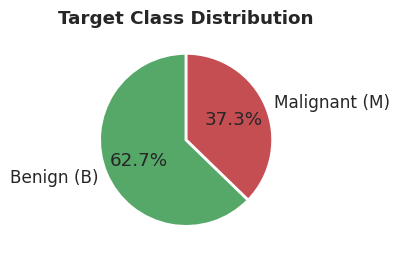

In [41]:
# Class distribution chart
fig, ax = plt.subplots(figsize=(4, 4))
cnt = y.value_counts()
ax.pie(cnt, labels=['Benign (B)', 'Malignant (M)'], autopct='%1.1f%%',
       colors=['#55A868', '#C44E52'], startangle=90,
       wedgeprops={'edgecolor': 'white', 'linewidth': 2})
ax.set_title('Target Class Distribution', fontweight='bold')
plt.tight_layout(); plt.show()

## 3. Algorithms & Predictions
> A shared `results` dict collects metrics for the final comparison.

In [42]:
results = {}

def show_results(name, y_true, y_pred):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1   = f1_score(y_true, y_pred, zero_division=0)
    results[name] = {'Accuracy': round(acc,4), 'Precision': round(prec,4),
                     'Recall': round(rec,4), 'F1': round(f1,4)}
    print('\n=== ' + name + ' ===')
    print(classification_report(y_true, y_pred, target_names=['Benign','Malignant']))
    fig, ax = plt.subplots(figsize=(4, 3))
    ConfusionMatrixDisplay.from_predictions(
        y_true, y_pred, display_labels=['Benign','Malignant'],
        colorbar=False, ax=ax, cmap='Blues')
    ax.set_title(name + ' — Confusion Matrix', fontweight='bold')
    plt.tight_layout(); plt.show()

### 3.1 Logistic Regression


=== Logistic Regression ===
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



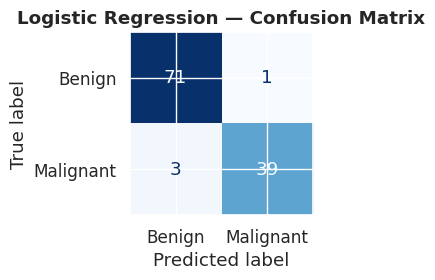

In [43]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_sc, y_train)
show_results('Logistic Regression', y_test, lr.predict(X_test_sc))

### 3.2 Support Vector Machine (SVM — RBF kernel)


=== SVM ===
              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98        72
   Malignant       1.00      0.93      0.96        42

    accuracy                           0.97       114
   macro avg       0.98      0.96      0.97       114
weighted avg       0.97      0.97      0.97       114



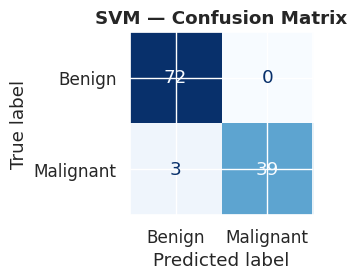

In [44]:
svm = SVC(kernel='rbf', probability=True, random_state=42)
svm.fit(X_train_sc, y_train)
show_results('SVM', y_test, svm.predict(X_test_sc))

### 3.3 K-Nearest Neighbours (KNN)

Best K: 5

=== KNN ===
              precision    recall  f1-score   support

      Benign       0.95      0.99      0.97        72
   Malignant       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



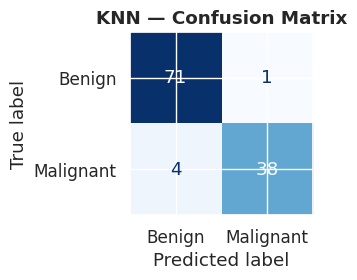

In [45]:
# Choose best K (1..20) by test accuracy
best_k = max(range(1, 21), key=lambda k:
    accuracy_score(y_test,
        KNeighborsClassifier(n_neighbors=k).fit(X_train_sc, y_train).predict(X_test_sc)))
print('Best K:', best_k)

knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_sc, y_train)
show_results('KNN', y_test, knn.predict(X_test_sc))

### 3.4 K-Means Clustering (Unsupervised)
> K-Means receives **no labels** during training. Clusters are mapped to classes after fitting.


=== K-Means (K=2) ===
              precision    recall  f1-score   support

      Benign       0.88      0.96      0.92        72
   Malignant       0.92      0.79      0.85        42

    accuracy                           0.89       114
   macro avg       0.90      0.87      0.88       114
weighted avg       0.90      0.89      0.89       114



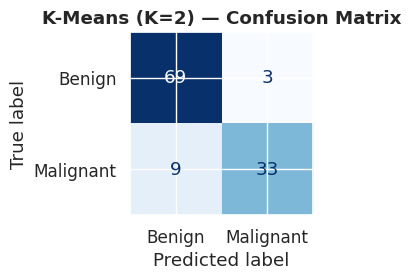

In [46]:
km = KMeans(n_clusters=2, random_state=42, n_init=10)
km.fit(X_train_sc)
km_labels = km.predict(X_test_sc)

# Align cluster IDs to true labels
aligned = np.zeros_like(km_labels)
for cid in np.unique(km_labels):
    mask = km_labels == cid
    aligned[mask] = mode(y_test.values[mask], keepdims=True).mode[0]

show_results('K-Means (K=2)', y_test, aligned)

### 3.5 Decision Tree — ID3 (Entropy criterion)

Best depth: 5

=== Decision Tree (ID3) ===
              precision    recall  f1-score   support

      Benign       0.95      0.99      0.97        72
   Malignant       0.97      0.90      0.94        42

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114



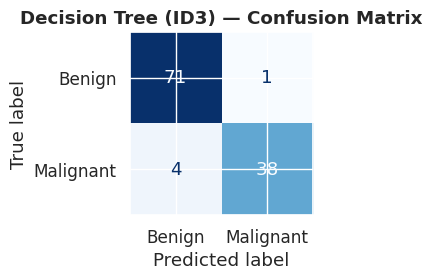

In [47]:
# Choose best depth (1..20)
best_d = max(range(1, 21), key=lambda d:
    accuracy_score(y_test,
        DecisionTreeClassifier(criterion='entropy', max_depth=d, random_state=42)
        .fit(X_train_sc, y_train).predict(X_test_sc)))
print('Best depth:', best_d)

dt = DecisionTreeClassifier(criterion='entropy', max_depth=best_d, random_state=42)
dt.fit(X_train_sc, y_train)
show_results('Decision Tree (ID3)', y_test, dt.predict(X_test_sc))

## 4. Performance Comparison

In [48]:
comp = pd.DataFrame(results).T.sort_values('Accuracy', ascending=False)
display(comp.style
        .background_gradient(cmap='RdYlGn')
        .format(precision=4)
        .set_caption('Higher is better for all metrics'))

,Accuracy,Precision,Recall,F1
SVM,0.9737,1.0000,0.9286,0.9630
Logistic Regression,0.9649,0.9750,0.9286,0.9512
KNN,0.9561,0.9744,0.9048,0.9383
Decision Tree (ID3),0.9561,0.9744,0.9048,0.9383
K-Means (K=2),0.8947,0.9167,0.7857,0.8462


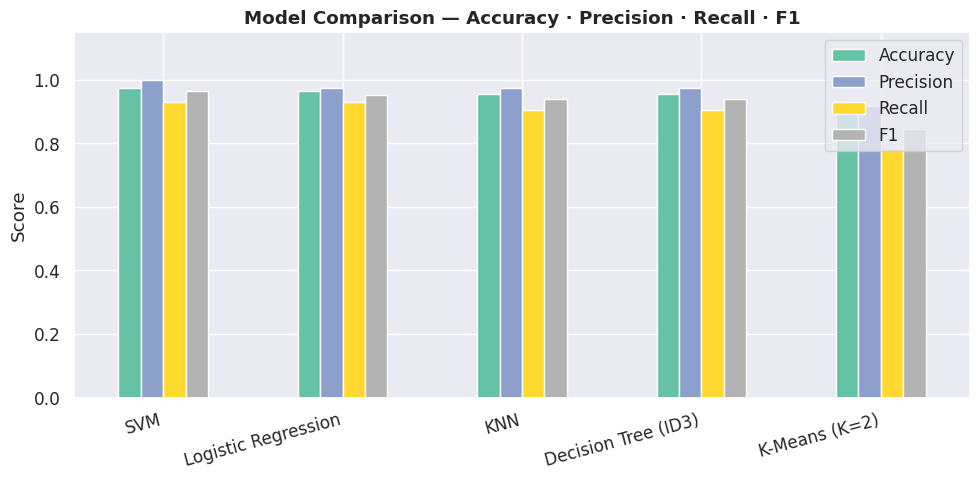

In [49]:
comp.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='white')
plt.title('Model Comparison — Accuracy · Precision · Recall · F1', fontweight='bold')
plt.xticks(rotation=15, ha='right')
plt.ylim(0, 1.15)
plt.ylabel('Score')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()